# Model Explainability

## Install

In [ ]:
#pip install "tranpy[explainability]"

## Setup

In [1]:
from tranpy.datasets import load_newengland
from tranpy.models import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = load_newengland(test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=50, max_depth=10)
model.fit(X_train, y_train)

accuracy = model.evaluate(X_test, y_test, verbose=False)['accuracy']
print(f"Model Accuracy: {accuracy:.3f}")

/Users/mahmouddraz/code/tranpy/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/mahmouddraz/code/tranpy/.venv/lib/python3.13/site-packages/dalex/_global_checks.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Model Accuracy: 0.988


## Feature Importance

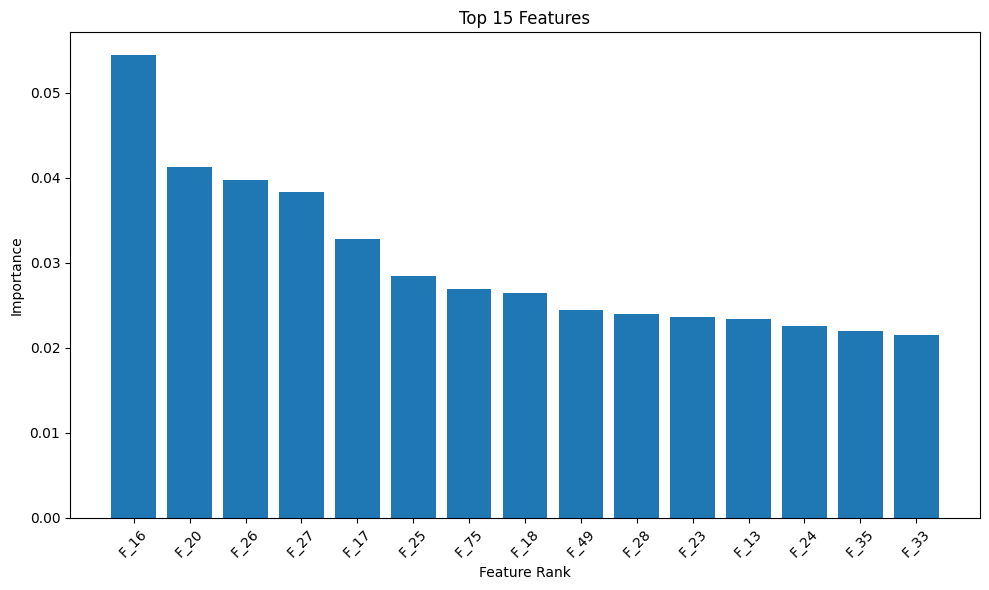

In [2]:
importances = model.model_.feature_importances_
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 6))
plt.bar(range(len(indices)), importances[indices])
plt.xlabel('Feature Rank')
plt.ylabel('Importance')
plt.title('Top 15 Features')
plt.xticks(range(len(indices)), [f'F_{i}' for i in indices], rotation=45)
plt.tight_layout()
plt.show()

## LIME Explainer

In [3]:
from tranpy.explainers import LIMEExplainer

explainer = LIMEExplainer(
    model=model,
    X_train=X_train[:1000],
    X_test=X_test[:100]
)

instance_idx = 1
instance = X_test[instance_idx]
pred = model.predict([instance])[0]
true = y_test[instance_idx]

print(f"Prediction: {pred}, True: {true}")

exp = explainer.explain_instance(instance, num_features=10)

print("\nTop 10 Feature Contributions:")
for feature, weight in exp.as_list()[:10]:
    print(f"{feature}: {weight:+.3f}")

Prediction: 1, True: 1
LIME explanation computed in 0.071s

Top 10 Feature Contributions:
F_75 > 12.81: +0.047
F_24 <= 0.61: +0.041
F_36 <= 0.67: +0.034
F_1 <= 0.63: +0.029
F_53 > -1.81: -0.024
F_63 > 0.16: +0.019
F_43 > -7.49: -0.016
F_15 <= 0.45: +0.015
F_29 <= 0.79: +0.013
F_49 > -1.50: -0.013


## LIME Visualization

In [4]:
# Workaround for IPython display import issue in LIME
from IPython.display import display, HTML

# Monkey patch to fix LIME's import
import sys
if 'IPython.core.display' in sys.modules:
    sys.modules['IPython.core.display'].display = display
    sys.modules['IPython.core.display'].HTML = HTML

exp.show_in_notebook(show_table=True)

## Compare Stable vs Unstable

In [5]:
stable_idx = np.where(y_test == 0)[0][0]
unstable_idx = np.where(y_test == 1)[0][0]

print("STABLE CASE:")
exp_stable = explainer.explain_instance(X_test[stable_idx], num_features=5)
for f, w in exp_stable.as_list()[:5]:
    print(f"  {f}: {w:+.3f}")

print("\nUNSTABLE CASE:")
exp_unstable = explainer.explain_instance(X_test[unstable_idx], num_features=5)
for f, w in exp_unstable.as_list()[:5]:
    print(f"  {f}: {w:+.3f}")

STABLE CASE:
LIME explanation computed in 0.239s
  F_75 > 12.81: +0.043
  F_1 <= 0.63: +0.024
  F_23 <= 0.40: -0.023
  F_53 > -1.81: -0.019
  F_2 <= 0.51: +0.018

UNSTABLE CASE:
LIME explanation computed in 0.218s
  F_75 > 12.81: +0.045
  F_24 <= 0.61: +0.042
  F_36 <= 0.67: +0.034
  F_1 <= 0.63: +0.029
  F_53 > -1.81: -0.022


## SHAP Explainer

In [6]:
from tranpy.explainers import SHAPExplainer

shap_explainer = SHAPExplainer(
    model=model,
    X_train=X_train[:500],
    X_test=X_test[:50]
)

# Compute SHAP values for all test instances
shap_values = shap_explainer.explain_global(use_cache=False)

print("SHAP values computed successfully")
print(f"Shape: {shap_values[1].shape if isinstance(shap_values, list) else shap_values.shape}")

Computing SHAP values...
SHAP values computed in 3.877s
SHAP values computed successfully
Shape: (50, 77)


## SHAP Summary Plot

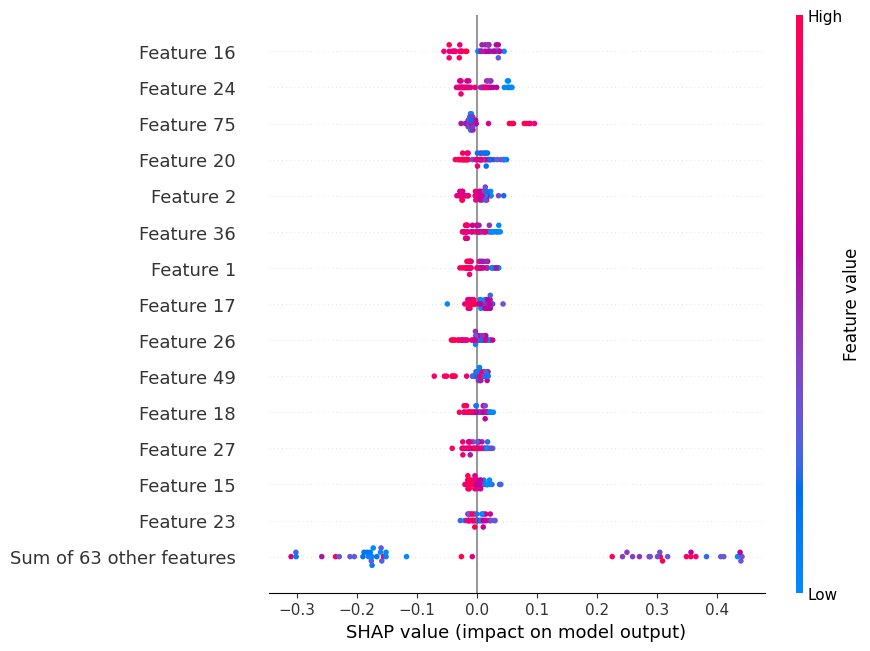

In [7]:
# Use the built-in plot_summary method
shap_explainer.plot_summary(
    shap_values=shap_values,
    X=X_test[:50],
    max_display=15
)

## SHAP Waterfall Plot

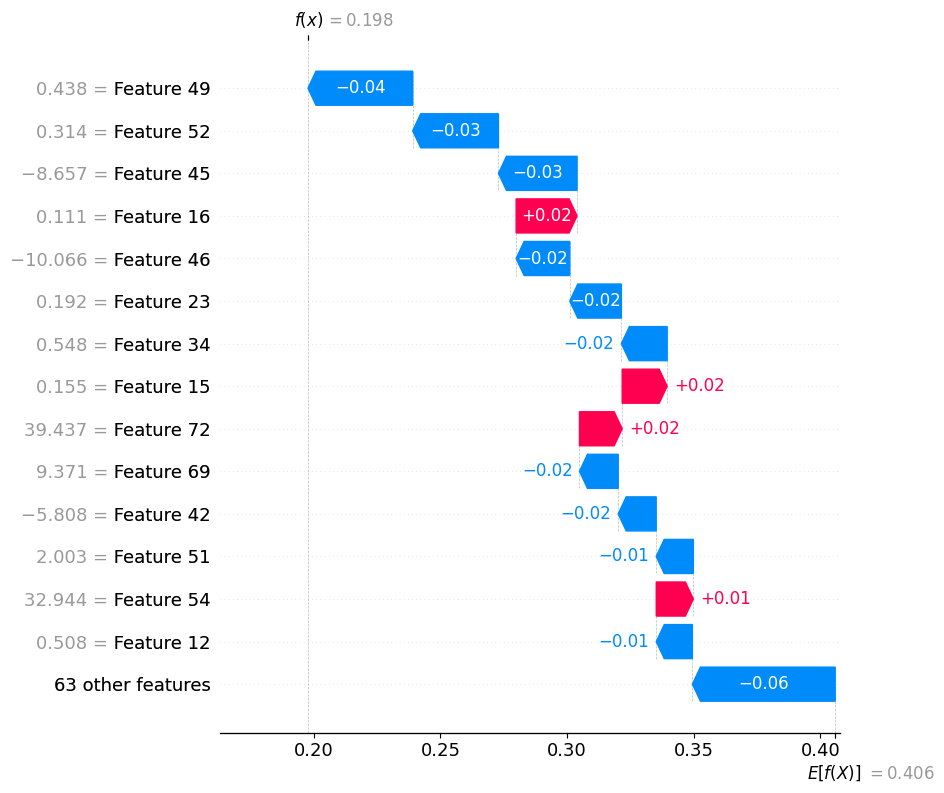

In [8]:
# Use the built-in plot_waterfall method
instance_idx = 0
shap_explainer.plot_waterfall(
    instance_idx=instance_idx,
    shap_values=shap_values,
    X=X_test[:50]
)

## DALEX Breakdown

In [9]:
from tranpy.explainers import BreakdownExplainer

breakdown = BreakdownExplainer(
    model=model,
    X_train=X_train[:1000],
    X_test=X_test[:50],
    y_test=y_test[:50]
)

instance_idx = 0
# Fix: pass the instance correctly as an integer index
bd_exp = breakdown.explain_instance(instance_idx)

print("Breakdown explanation:")
print(bd_exp.result)

Preparation of a new explainer is initiated

  -> data              : 50 rows 77 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 50 values
  -> model_class       : tranpy.models.classical.RandomForestClassifier (default)
  -> label             : Power System Stability - RandomForestClassifier
  -> predict function  : <function yhat_proba_default at 0x11b0f4180> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.00052, mean = 0.488, max = 0.999
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.532, mean = -0.0084, max = 0.493
  -> model_info        : package tranpy

A new explainer has been created!
Breakdown explanation:
   variable_name variable_value       variable  cumulative  contribution  \
0      intercept                     

## DALEX Breakdown Plot

In [10]:
bd_exp.plot()

## DALEX Surrogate

In [11]:
from tranpy.explainers import SurrogateExplainer

surrogate = SurrogateExplainer(
    model=model,
    X_train=X_train[:1000],
    X_test=X_test[:50],
    y_test=y_test[:50]
)

# Use explain_global() to get feature importances
importances = surrogate.explain_global(max_iter=5000)

print("Surrogate model feature importances:")
print(importances.head(10))

Generating predictions from complex model...
Training surrogate logistic regression model...
Surrogate model fidelity (R²): 0.6779
Surrogate model accuracy: 0.9000
Surrogate model feature importances:
  feature_name  importance
0         F_42    1.443859
1         F_40    1.138637
2         F_69    1.045067
3         F_49    0.987430
4         F_53    0.948805
5         F_48    0.891451
6         F_61    0.867850
7         F_73    0.808908
8         F_44    0.776787
9         F_64    0.760968


## DALEX Surrogate Plot

In [12]:
# surrogate_exp.plot()
# Plot cell removed since variable name changed

print("Surrogate explainer completed")

Surrogate explainer completed


## Batch Explanations

In [13]:
n_samples = 10
print(f"Explaining {n_samples} instances with LIME...")

for i in range(n_samples):
    exp = explainer.explain_instance(X_test[i], num_features=5)
    pred = model.predict([X_test[i]])[0]
    print(f"\nInstance {i} (Pred: {pred}, True: {y_test[i]}):")
    for f, w in exp.as_list()[:3]:
        print(f"  {f}: {w:+.3f}")

Explaining 10 instances with LIME...
LIME explanation computed in 0.252s

Instance 0 (Pred: 0, True: 0):
  F_75 > 12.81: +0.044
  F_1 <= 0.63: +0.022
  F_43 > -7.49: -0.021
LIME explanation computed in 0.219s

Instance 1 (Pred: 1, True: 1):
  F_75 > 12.81: +0.043
  F_24 <= 0.61: +0.033
  F_36 <= 0.67: +0.032
LIME explanation computed in 0.246s

Instance 2 (Pred: 1, True: 1):
  F_38 <= 0.93: +0.027
  F_10 <= 0.30: +0.015
  F_51 <= -6.01: +0.015
LIME explanation computed in 0.224s

Instance 3 (Pred: 1, True: 1):
  F_1 > 0.79: -0.019
  F_23 <= 0.40: -0.017
  F_36 > 0.81: -0.017
LIME explanation computed in 0.225s

Instance 4 (Pred: 0, True: 0):
  -7.04 < F_75 <= 7.07: -0.019
  F_38 <= 0.93: +0.019
  F_18 > 0.79: -0.018
LIME explanation computed in 0.225s

Instance 5 (Pred: 0, True: 0):
  F_38 <= 0.93: +0.026
  F_24 > 0.79: -0.017
  F_18 > 0.79: -0.017
LIME explanation computed in 0.220s

Instance 6 (Pred: 1, True: 1):
  F_75 > 12.81: +0.044
  F_1 <= 0.63: +0.026
  0.61 < F_24 <= 0.75: -0.